In [ ]:
import numpy as np 
import pandas as pd
import tensorflow as tf
import sklearn.model_selection
from tensorflow.keras.models import Model
import tensorflow.keras.models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


In [13]:
# set random 
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# generating fake data 

# weather: 1d time series 
# generating w/ temperature, humidity, pressure 
num_sample = 1000 
time_steps = 24 # number of time steps 
weather_features = 3 # estatblished above w/ temp, humidity, pressure

In [28]:
# let the time series shape be (num_samples, time_series, features)
X_weather = np.random.rand(num_sample,time_spot, weather_feature)

In [45]:
# patient data and social
num_tabular_features = 10
X_tabular = np.random.rand(num_sample, num_tanular_features)

# binary label of heart attack events: 1 = heart attack, 0 = no heart attack
y = np.random.randint(0, 2, size=(num_sample, 1))

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
# split the training and testing data 8/2 split 
X_weather_train, X_weather_test, X_tabular_train, X_tabular_test, y_train, y_test =train_test_split(
  X_weather, X_tabular, y, test_size=0.2, random_state=42
)

In [32]:
# print the shape of the df
print("weather data train:", X_weather_train.shape)
print("tubular data train:", X_tabular_train.shape)
print("label train shape:", y_train.shape)

weather data train: (800, 24, 3)
tubular data train: (800, 10)
label train shape: (800, 1)


In [33]:
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D, Flatten,
                                     Dense, Dropout, Concatenate)

In [ ]:
# building model for 1d CNN for weather data

# input shape: (time_steps, westher_features)
weather_input = Input(shape=(time_steps, weather_features), name='weather_input')
x = Conv1D(filters=32, kernel_size=3, activation='relu')(weather_input)
x = MaxPooling1D(pool_size=2)(x)
x = Conv1D(filters=64, kernel_size=3, activation='relu')(x)
x = MaxPooling1D(pool_size=2)(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)

# regularize the data
weather_branch = Dropout(.5)(x)

In [ ]:
# tabular data 
# Input shape: (num_tabular_features,)
tabular_input = Input(shape=(num_tabular_features,), name='tabular_input')
y_branch = Dense(64, activation='relu')(tabular_input)
y_branch = Dropout(0.5)(y_branch)
y_branch = Dense(64, activation='relu')(y_branch)
y_branch = Dense(128, activation='relu')(y_branch)

In [48]:
# fusion to add features from both branches 
merged = Concatenate()([weather_branch, y_branch])
z = Dense(64, activation='relu')(merged)
z = Dropout(0.5)(z)
z = Dense(32, activation='relu')(z)

# classify binary output using sigmoid activation for probability  
output = Dense(1, activation='sigmoid', name='output')(z)

# build model 
model = Model(inputs=[weather_input, tabular_input], outputs=output)

# compil eusing binary cossentropy & adam opt
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ weather_input       │ (None, 24, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 22, 32)    │        320 │ weather_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 11, 32)    │          0 │ conv1d_3[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 9, 64)     │      6,208 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 4, 64)     │          0 │ conv1d_4[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        704 │ tabular_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 256)       │          0 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     32,896 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │      8,320 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │     16,448 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 71,169 (278.00 KB)

 Trainable params: 71,169 (278.00 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
# training

# set up earlystopping & callback 
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# train the model
history = model.fit(
  [X_weather_train, X_tabular_train],
  y_train, 
  validation_split=0.2,
  epochs=50,
  batch_size=32,
  callbacks=[early_stop]
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5298 - loss: 0.6925 - val_accuracy: 0.5125 - val_loss: 0.6927
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4885 - loss: 0.6981 - val_accuracy: 0.4875 - val_loss: 0.6928
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4786 - loss: 0.6996 - val_accuracy: 0.4750 - val_loss: 0.6930
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4640 - loss: 0.6998 - val_accuracy: 0.4688 - val_loss: 0.6930
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5276 - loss: 0.6920 - val_accuracy: 0.4750 - val_loss: 0.6932
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4970 - loss: 0.6967 - val_accuracy: 0.4812 - val_loss: 0.6936


In [52]:
# model validation

# evaluate model on the test set
test_loss, test_accuracy  = model.evaluate([X_weather_test, X_tabular_test], y_test)

print("test loss:", test_loss)
print("test accurarcy:", test_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5272 - loss: 0.6924  
test loss: 0.6926778554916382
test accurarcy: 0.5099999904632568


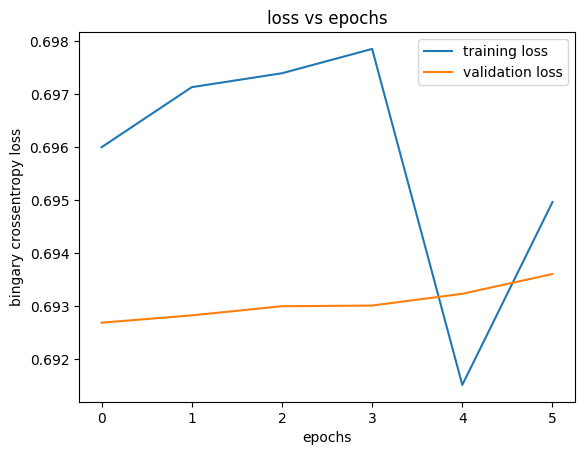

In [69]:
# ploting visalization

# plt.figure(figsize=(8, 5))
# plot for training, loss, accurarcy 
# plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.title('loss vs epochs')
plt.xlabel('epochs')
plt.ylabel('bingary crossentropy loss')
plt.legend()

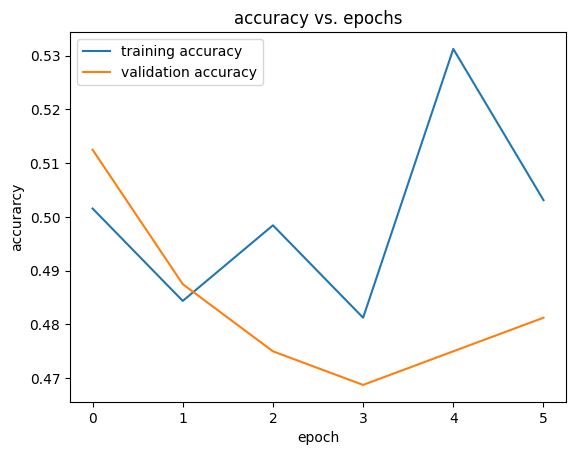

In [70]:
# accuracy plot 
# plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.title('accuracy vs. epochs')
plt.xlabel('epoch')
plt.ylabel('accurarcy')
plt.legend()